In [39]:
!pip install python-Levenshtein

In [40]:
import csv
import os
import random
from pathlib import Path
from typing import List, Dict
from tqdm import tqdm

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms

import Levenshtein

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

device = torch.device("cuda")

In [41]:
def find_contours(dimensions, img):
    cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lower_width, upper_width, lower_height, upper_height = dimensions
    
    # Sort contours by area to filter out tiny noise first
    cntrs = sorted(cntrs, key=cv2.contourArea, reverse=True)[:15]

    img_res = []
    for cntr in cntrs:
        intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)
        
        # Check if the contour fits the logic of a digit
        if (intWidth > lower_width and intWidth < upper_width and 
            intHeight > lower_height and intHeight < upper_height):
            
            # Extract the character from the BINARY image
            char = img[intY:intY + intHeight, intX:intX + intWidth]
            
            # Resize with Aspect Ratio preservation
            char = cv2.resize(char, (20, 40))
            
            # Create the 44x24 canvas (Black background, White digit)
            char_copy = np.zeros((44, 24), dtype=np.uint8)
            char_copy[2:42, 2:22] = char 
            
            img_res.append((intX, char_copy))

    # Sort characters from LEFT to RIGHT based on X position
    img_res = sorted(img_res, key=lambda t: t[0])
    
    return np.array([x[1] for x in img_res])

In [42]:
def segment_characters(image):
    
    if image is None or image.size == 0:
        return np.empty((0, 44, 24), dtype=np.uint8)
    
    img_lp = cv2.resize(image, (333, 75))
    gray = cv2.cvtColor(img_lp, cv2.COLOR_BGR2GRAY) if len(img_lp.shape)==3 else img_lp
    
    binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                    cv2.THRESH_BINARY_INV, 29, 9)
        
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    h, w = binary.shape
    dims = [w * 0.02723, w * 0.18847, h * 0.25341, h * 0.81407]
    
    return find_contours(dims, binary)

In [43]:
def segment_hybrid_precision(image):
    if image is None or image.size == 0:
        return np.empty((0, 44, 24), dtype=np.uint8)

    img_lp = cv2.resize(image, (333, 75))
    gray = cv2.cvtColor(img_lp, cv2.COLOR_BGR2GRAY) if len(img_lp.shape)==3 else img_lp
    
    # Aggressive Noise Reduction
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    
    # Adaptive Thresholding with wide block size
    binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 43, 12)

    # Aggressive Frame Removal
    h, w = binary.shape
    binary[0:int(h*0.11), :] = 0  # Top 15%
    binary[int(h*0.89):h, :] = 0  # Bottom 15%
    binary[:, 0:int(w*0.0295)] = 0  # Left 5%
    binary[:, int(w*0.9705):w] = 0  # Right 5%

    # Find Contours
    cntrs, _ = cv2.findContours(binary.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Loose Filter to get all potential candidates
    candidates = []
    for cntr in cntrs:
        x, y, w_c, h_c = cv2.boundingRect(cntr)
        if (w_c < w * 0.227) and (h_c > h * 0.268): 
            candidates.append({'x': x, 'y': y, 'w': w_c, 'h': h_c, 'cntr': cntr})

    if len(candidates) == 0:
        return np.array([])

    # Find the most common Y-center. Digits always form a straight line.
    y_centers = [c['y'] + c['h']/2 for c in candidates]
    median_y = np.median(y_centers)
    median_h = np.median([c['h'] for c in candidates])

    final_chars = []
    for c in candidates:
        y_center = c['y'] + c['h']/2
        # If it's on the main horizontal band AND has a logical aspect ratio
        if abs(y_center - median_y) < (median_h * 0.588):
            # Split detection: if it's very wide, it's 2 digits
            if c['w'] > (c['h'] * 0.973):
                w_half = c['w'] // 2
                # Split and add both
                for i in range(2):
                    char_crop = binary[c['y']:c['y']+c['h'], c['x'] + (i*w_half) : c['x'] + ((i+1)*w_half)]
                    final_chars.append((c['x'] + (i*w_half), char_crop))
            else:
                char_crop = binary[c['y']:c['y']+c['h'], c['x']:c['x']+c['w']]
                final_chars.append((c['x'], char_crop))

    # Formatting
    final_chars = sorted(final_chars, key=lambda t: t[0])
    output = []
    for _, char_img in final_chars:
        char_res = cv2.resize(char_img, (20, 40))
        canvas = np.zeros((44, 24), dtype=np.uint8)
        canvas[2:42, 2:22] = char_res
        output.append(canvas)

    return np.array(output)

In [44]:
def segment_hybrid_precision_v2(image):
    if image is None or image.size == 0:
        return np.empty((0, 44, 24), dtype=np.uint8)

    # Standardize and Preprocess
    img_lp = cv2.resize(image, (333, 75))
    gray = cv2.cvtColor(img_lp, cv2.COLOR_BGR2GRAY) if len(img_lp.shape)==3 else img_lp
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    
    # Adaptive Thresholding
    binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 43, 12)

    # Aggressive Frame Removal (Stay with your tuned values)
    h, w = binary.shape
    binary[0:int(h*0.11), :] = 0  
    binary[int(h*0.89):h, :] = 0  
    binary[:, 0:int(w*0.0295)] = 0  
    binary[:, int(w*0.9705):w] = 0  

    # Find Contours
    cntrs, _ = cv2.findContours(binary.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    candidates = []
    for cntr in cntrs:
        x, y, w_c, h_c = cv2.boundingRect(cntr)
        
        # Solidity = Area of contour / Area of bounding box
        # Real digits usually have solidity between 0.3 and 0.8
        area = cv2.contourArea(cntr)
        solidity = area / float(w_c * h_c) if w_c * h_c > 0 else 0
        
        if (w_c < w * 0.227) and (h_c > h * 0.268) and (0.2 < solidity < 0.9):
            candidates.append({'x': x, 'y': y, 'w': w_c, 'h': h_c, 'solidity': solidity})

    if not candidates:
        return np.array([])

    # SPATIAL CONSENSUS
    y_centers = [c['y'] + c['h']/2 for c in candidates]
    median_y = np.median(y_centers)
    median_h = np.median([c['h'] for c in candidates])
    # Median width helps us identify fused digits more accurately than a hard constant
    median_w = np.median([c['w'] for c in candidates])

    final_chars = []
    for c in candidates:
        y_center = c['y'] + c['h']/2
        if abs(y_center - median_y) < (median_h * 0.588):
            
            # Dynamic Split Logic 
            # If the blob is significantly wider than the other characters on THIS plate
            if c['w'] > (median_w * 1.6): 
                w_half = c['w'] // 2
                for i in range(2):
                    char_crop = binary[c['y']:c['y']+c['h'], c['x'] + (i*w_half) : c['x'] + ((i+1)*w_half)]
                    final_chars.append((c['x'] + (i*w_half), char_crop))
            else:
                char_crop = binary[c['y']:c['y']+c['h'], c['x']:c['x']+c['w']]
                final_chars.append((c['x'], char_crop))

    # Formatting
    final_chars = sorted(final_chars, key=lambda t: t[0])
    output = []
    for _, char_img in final_chars:
        # Final sanity check: skip very thin noise that might have survived
        if char_img.shape[1] < 2: continue 
            
        char_res = cv2.resize(char_img, (20, 40))
        canvas = np.zeros((44, 24), dtype=np.uint8)
        canvas[2:42, 2:22] = char_res
        output.append(canvas)

    return np.array(output)

In [45]:
def ensemble_voting_system(image):
    
    # Get results from all specialists
    chars1 = segment_characters(image)
    chars2 = segment_hybrid_precision(image)
    chars3 = segment_hybrid_precision_v2(image)
    
    results = [chars1, chars2, chars3]
    lengths = [len(chars1), len(chars2), len(chars3)]
    valid_lengths = [10, 11]
    
    # Check which functions produced valid lengths
    valid_mask = [l in valid_lengths for l in lengths]
    
    # LOGIC 1: Multiple Valid Hits (Consensus) 
    if sum(valid_mask) > 1:
        if valid_mask[1]: 
            return chars2
        elif valid_mask[2]:
            return chars3
        return chars1

    # LOGIC 2: Single Valid Hit 
    if sum(valid_mask) == 1:
        # Find the index of the True value
        winner_idx = valid_mask.index(True)
        return results[winner_idx]

    # LOGIC 3: Recovery Mode (No one hit 10 or 11)
    # We find the result closest to the 10-11 range.
    distances = [abs(l - 10.5) for l in lengths]
    min_distance = min(distances)
    
    # If there's a tie in distance, we prefer Function 3 
    # because it has the lowest noise (over-segmentation)
    best_indices = [i for i, d in enumerate(distances) if d == min_distance]
    
    if 2 in best_indices: 
        return chars3
    elif 1 in best_indices: 
        return chars2
    else:
        return chars1

In [46]:
def visualize_segmentation(plate_img: np.ndarray):
    chars = segment_characters(plate_img)
    if len(chars) == 0:
        chars = ensemble_voting_system(plate_img)

    if len(chars) == 0:
        print("No characters segmented.")
        return

    n = len(chars)
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, ch in zip(axes, chars):
        ax.imshow(ch, cmap="gray")
        ax.axis("off")
    plt.show()

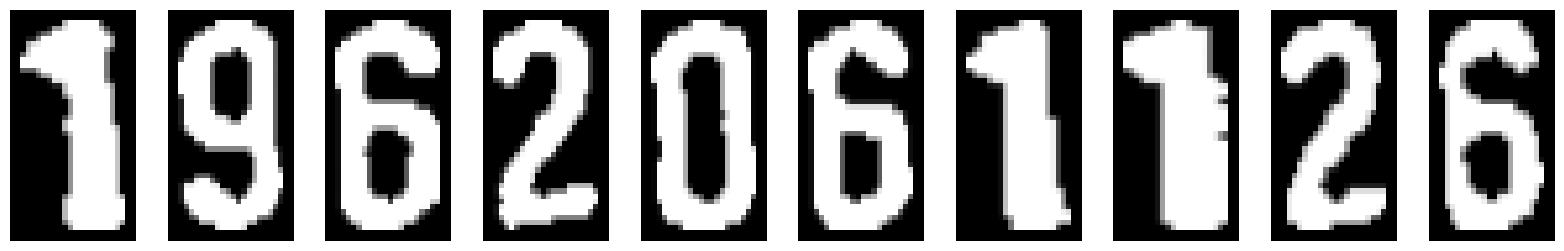

In [47]:
plate = cv2.imread('/kaggle/input/datasets/tobniislam/lp-dataset/LP Data/Images/02f2b39a-img_1876_box0.png')
visualize_segmentation(plate)

In [48]:
def evaluate_segmentation_performance(csv_path, img_dir):
    df = pd.read_csv(csv_path, dtype={'text': str})
    total_samples = len(df)
    correct_count = 0
    under_segmented = 0 # Found fewer digits than expected
    over_segmented = 0  # Found more digits than expected (noise)
    
    print(f"Evaluating {total_samples} images...")
    
    for _, row in tqdm(df.iterrows(), total=total_samples):
        img_path = os.path.join(img_dir, row['file_name'])
        image = cv2.imread(img_path)
        
        if image is None:
            continue
            
        chars = ensemble_voting_system(image)
        
        predicted_len = len(chars)
        actual_len = len(str(row['text']))
        
        if predicted_len == actual_len:
            correct_count += 1
        elif predicted_len < actual_len:
            under_segmented += 1
        else:
            over_segmented += 1
            
    accuracy = (correct_count / total_samples) * 100
    print(f"\n--- Segmentation Results ---")
    print(f"Perfect Match Accuracy: {accuracy:.2f}%")
    print(f"Under-segmented (Missed chars): {under_segmented}")
    print(f"Over-segmented (Detected noise): {over_segmented}")
    
    return accuracy

evaluate_segmentation_performance("/kaggle/input/datasets/tobniislam/correct-lp-dataset/lp_dataset.csv",
                                  "/kaggle/input/datasets/tobniislam/lp-dataset/LP Data/Images")

Evaluating 2078 images...


100%|██████████| 2078/2078 [00:13<00:00, 157.56it/s]


--- Segmentation Results ---
Perfect Match Accuracy: 74.40%
Under-segmented (Missed chars): 311
Over-segmented (Detected noise): 221


74.39846005774784

In [49]:
# Configuration + Model Loading
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Test transforms 
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [50]:
class DigitClassifierTL(nn.Module): 
    def __init__(self, num_classes=10):
        super(DigitClassifierTL, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [51]:
model = DigitClassifierTL().to(device)
model.load_state_dict(torch.load('/kaggle/input/models/tobniislam/best-digits-seg-model/pytorch/default/1/best_digit_model.pth'))
model.eval()

DigitClassifierTL(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=100352, out_features=256, bias=True)
    (11): ReLU()
    (12): Dropout(p=0.5, inplace=False)
    (13): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [52]:
def recognize_characters(chars_list, model):
    """
    Takes a list of segmented NumPy character images and returns the predicted string.
    """
    predicted_text = ""
    
    for char_np in chars_list:
        # Convert Grayscale NumPy array (44x24) to RGB PIL Image
        char_pil = Image.fromarray(char_np).convert('RGB')

        input_tensor = test_transforms(char_pil).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            # Get the index of the highest prediction
            pred_label = output.argmax(1).item()
            predicted_text += str(pred_label)
            
    return predicted_text

In [53]:
# The Master Function 
def get_license_plate_text(image_path):
    """
    The full 'End-to-End' process: Path -> Image -> Segmentation -> Recognition -> Text
    """
    # Load the cropped license plate image
    plate_img = cv2.imread(image_path)
    if plate_img is None:
        return "Error: Image not found"

    # The Ensemble Voting System 
    segmented_chars = ensemble_voting_system(plate_img)
    
    if len(segmented_chars) == 0:
        return "No characters detected"

    # The Recognition Model
    full_text = recognize_characters(segmented_chars, model)
    
    return full_text

Detected Plate: 2413719816


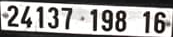

In [54]:
img_path = '/kaggle/input/datasets/tobniislam/lp-dataset/LP Data/Images/0367cfeb-img_1000_box0.png'
plate_text = get_license_plate_text(img_path)
print(f"Detected Plate: {plate_text}")
Image.open(img_path)

In [55]:
def calculate_global_performance(csv_path, img_dir, model):
    
    # Load dataset
    df = pd.read_csv(csv_path, dtype={'text': str})
    total_samples = len(df)
    
    # Tracking metrics
    lev_distances = []
    perfect_matches = 0
    err_le_1 = 0  # Error <= 1
    err_le_2 = 0  # Error <= 2
    err_le_3 = 0  # Erroe <= 3

    # Groups for visualization
    groups = {
        "correct": [],        # Distance = 0
        "near_miss": [],      # Distance 1 or 2
        "fail": []            # Distance > 2
    }

    # For Confusion Matrix
    all_true_digits = []
    all_pred_digits = []
    
    print(f"Starting Global Evaluation on {total_samples} images...")
    model.eval()

    for _, row in tqdm(df.iterrows(), total=total_samples):
        img_path = os.path.join(img_dir, row['file_name'])
        ground_truth = str(row['text']).strip()
        
        # Run the full pipeline
        try:
            predicted_text = get_license_plate_text(img_path)
        except Exception as e:
            # Fallback for failed reads/segmentations
            predicted_text = ""
        
        # Calculate Levenshtein Distance
        dist = Levenshtein.distance(predicted_text, ground_truth)
        lev_distances.append(dist)

        # Grouping Logic
        result_entry = {
            "file_name": row['file_name'],
            "true": ground_truth,
            "pred": predicted_text,
            "dist": dist
        }
        
        # Aggregate Performance
        if dist == 0:
            groups["correct"].append(result_entry)
            perfect_matches += 1
        if dist <= 1:
            err_le_1 += 1
        if dist <= 2:
            err_le_2 += 1
        if dist <=3:
            err_le_3 += 1
        if 1<=dist<=2:
            groups["near_miss"].append(result_entry)
        if dist>2:
            groups["fail"].append(result_entry)

        # Confusion Matrix Logic
        # We only compare digits if the lengths match to ensure correct alignment
        if len(predicted_text) == len(ground_truth):
            for t_char, p_char in zip(ground_truth, predicted_text):
                if t_char.isdigit() and p_char.isdigit():
                    all_true_digits.append(int(t_char))
                    all_pred_digits.append(int(p_char))

    # Final Metric Calculations
    acc_perfect = (perfect_matches / total_samples) * 100
    acc_le_1 = (err_le_1 / total_samples) * 100
    acc_le_2 = (err_le_2 / total_samples) * 100
    acc_le_3 = (err_le_3 / total_samples) * 100
    avg_dist = np.mean(lev_distances)

    # Display Results
    print("\n" + "="*40)
    print(" =======  FINAL GLOBAL RESULTS  =======")
    print("="*40)
    print(f"Total Plates Evaluated:  {total_samples}")
    print(f"Average Edit Distance:   {avg_dist:.2f} chars")
    print("-" * 40)
    print(f"- Exact Match Accuracy:      {acc_perfect:.2f}%")
    print(f"- Accuracy (≤ 1 Error):     {acc_le_1:.2f}%")
    print(f"- Accuracy (≤ 2 Errors):    {acc_le_2:.2f}%")
    print(f"- Accuracy (≤ 3 Errors):    {acc_le_3:.2f}%")
    print("="*40)

    # --- Visualization: Confusion Matrix ---
    cm = confusion_matrix(all_true_digits, all_pred_digits, labels=list(range(10)))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(10), yticklabels=range(10))
    plt.title("Digit Recognition Confusion Matrix\n(Aligned Plates Only)")
    plt.xlabel("Predicted Digit")
    plt.ylabel("True Digit")
    plt.show()

    return {
        "perfect": acc_perfect,
        "le_1": acc_le_1,
        "le_2": acc_le_2,
        "le_3": acc_le_3,
        "groups": groups
    }

Starting Global Evaluation on 2078 images...


100%|██████████| 2078/2078 [01:04<00:00, 32.46it/s]



 =======  FINAL GLOBAL RESULTS  =======
Total Plates Evaluated:  2078
Average Edit Distance:   1.63 chars
----------------------------------------
- Exact Match Accuracy:      60.97%
- Accuracy (≤ 1 Error):     74.74%
- Accuracy (≤ 2 Errors):    81.38%
- Accuracy (≤ 3 Errors):    84.31%


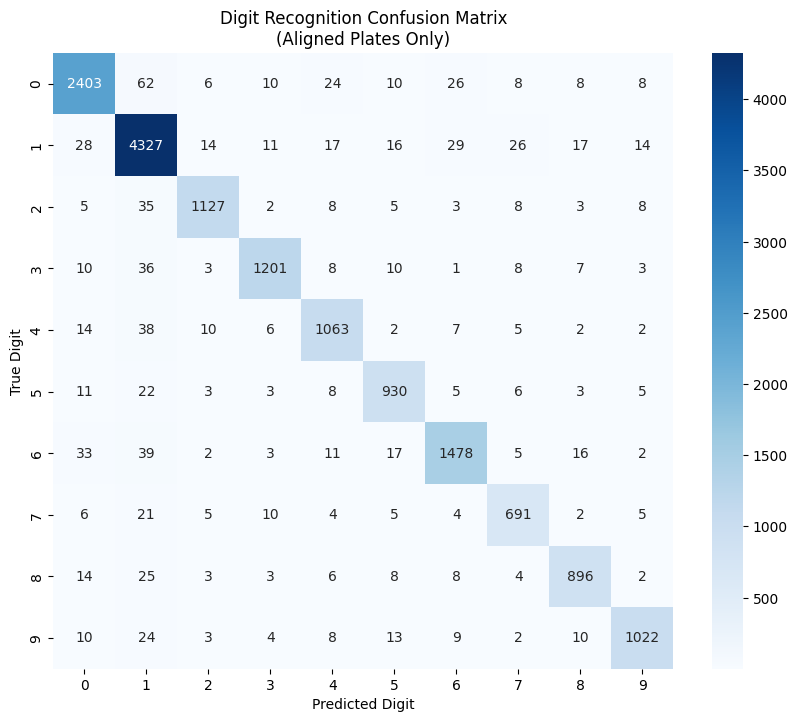

In [56]:
# Execute the evaluation
results = calculate_global_performance(
    "/kaggle/input/datasets/tobniislam/correct-lp-dataset/lp_dataset.csv",
    "/kaggle/input/datasets/tobniislam/lp-dataset/LP Data/Images",
    model
)

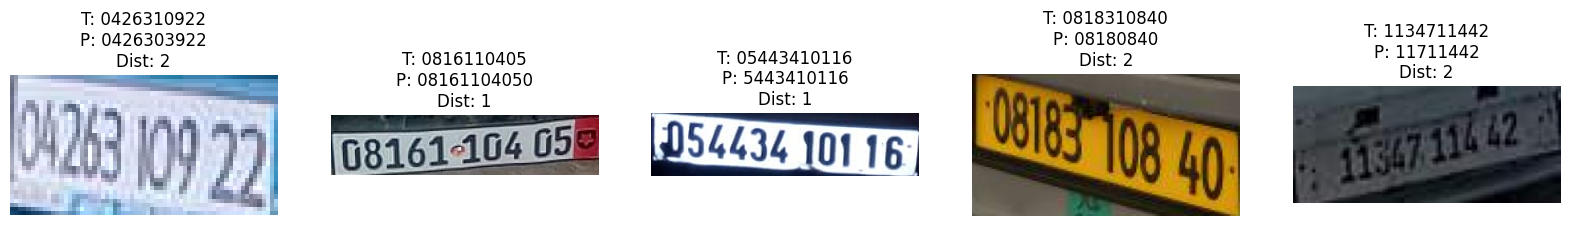

In [57]:
def visualize_error_group(group_list, img_dir, num_samples=5):

    samples = random.sample(group_list, min(num_samples, len(group_list)))
    
    plt.figure(figsize=(20, 4))
    for i, item in enumerate(samples):
        img_path = os.path.join(img_dir, item['file_name'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"T: {item['true']}\nP: {item['pred']}\nDist: {item['dist']}")
        plt.axis('off')
    plt.show()

visualize_error_group(results['groups']["near_miss"], 
                      "/kaggle/input/datasets/tobniislam/lp-dataset/LP Data/Images")